Jena Climateのデータに対して、patchtstを適用してみる

In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

In [23]:
import os
import urllib.request
import zipfile
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = "jena_climate.zip"
csv_path = "jena_climate_2009_2016.csv"

if not os.path.exists(csv_path):
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()



In [24]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
df = pd.read_csv(csv_path)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [25]:
df = df.drop('Date Time', axis=1)
n = len(df)
train_df = df[0:int(n * 0.7)]
val_df = df[int(n * 0.7):int(n * 0.8)]
test_df = df[int(n * 0.8):]
scaler = StandardScaler()
train_data = scaler.fit_transform(train_df.values)
val_data = scaler.transform(val_df.values)
test_data = scaler.transform(test_df.values)




In [26]:
print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}, Test samples: {len(test_df)}")

Train samples: 294385, Val samples: 42055, Test samples: 84111


簡単にそれぞれの時系列の長さの意図を説明する
本来kaggleのコンペなどでは、あらかじめデータに合わせて長さを調整(6*24*7)のようにするが、今回はモデルの訓練時間等を考えてこの大きさにしている
さらに、今回、いままでjeneのデータセット予測では日データにしていたが、今回は１０分ごとにしているのはデータの数を確保し、それだけでは逆に多いので、+18ずらし手作っている

In [41]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len=512, pred_len=96, step=18): 
        self.data = torch.FloatTensor(data)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.step = step
        
    def __len__(self):
        # 取得可能な窓の総数を歩幅で割る
        return (len(self.data) - self.seq_len - self.pred_len) // self.step + 1
        
    def __getitem__(self, idx):
        # 実際のインデックスに歩幅を掛ける
        real_idx = idx * self.step 
        x = self.data[real_idx : real_idx + self.seq_len]
        y = self.data[real_idx + self.seq_len : real_idx + self.seq_len + self.pred_len]
        return x, y

seq_len = 512
pred_len = 96
batch_size = 32

train_dataset = TimeSeriesDataset(train_data, seq_len, pred_len)
val_dataset = TimeSeriesDataset(val_data, seq_len, pred_len)
test_dataset = TimeSeriesDataset(test_data, seq_len, pred_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

# バッチの形状確認
x_batch, y_batch = next(iter(train_loader))
print(f"X batch shape: {x_batch.shape}")  #約3.5日文
print(f"Y batch shape: {y_batch.shape}")  #１６時間分

X batch shape: torch.Size([32, 512, 14])
Y batch shape: torch.Size([32, 96, 14])


In [33]:
len(train_loader), len(val_loader), len(test_loader)

(510, 71, 145)

事前学習をしていく Trainerに関しては今回は使わない
まだまだ、誤差は落ちていきそうだけど、ここらへんでstop(時間の関係)

In [34]:
from transformers import PatchTSTConfig,PatchTSTForPretraining
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = PatchTSTConfig(
    num_input_channels=14,            # 変数の数 (Jena Climate)
    context_length=512,               # 入力長 (Context Window)
    patch_length=16,                  # パッチの長さ
    stride=8,                         # パッチをスライドさせる幅
    mask_input=True,                  # 事前学習のマスキングを有効化
    mask_ratio=0.4,                   # 40%のパッチを隠す
    mask_type="random",               # ランダムに隠す
    use_reversible_instance_norm=True # Instance Normのところ、論文のように、入る前に正規化、そのご予測の前に逆正規化をして、冬でも夏でもスケールを同じにして、波の形だけを学習するようにする
)

model = PatchTSTForPretraining(config).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

import copy
import torch

num_epochs = 30
patience = 5  
best_val_loss = float('inf')
best_model_weights = None
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        outputs = model(past_values=x_batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x_val, _ in val_loader:
            x_val = x_val.to(device)
            val_outputs = model(past_values=x_val)
            val_loss = val_outputs.loss
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # --- Early Stopping の判定 ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict()) 
        patience_counter = 0 
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

# 学習完了後、一番性能が良かった時の重みをモデルに戻す
model.load_state_dict(best_model_weights)
print("Best model restored.")

Epoch [1/30] Train Loss: 0.3554 | Val Loss: 0.2217
Epoch [2/30] Train Loss: 0.1923 | Val Loss: 0.1853
Epoch [3/30] Train Loss: 0.1658 | Val Loss: 0.1625
Epoch [4/30] Train Loss: 0.1512 | Val Loss: 0.1595
Epoch [5/30] Train Loss: 0.1439 | Val Loss: 0.1431
Epoch [6/30] Train Loss: 0.1203 | Val Loss: 0.1143
Epoch [7/30] Train Loss: 0.1058 | Val Loss: 0.1044
Epoch [8/30] Train Loss: 0.0927 | Val Loss: 0.0872
Epoch [9/30] Train Loss: 0.0745 | Val Loss: 0.0661
Epoch [10/30] Train Loss: 0.0604 | Val Loss: 0.0595
Epoch [11/30] Train Loss: 0.0554 | Val Loss: 0.0541
Epoch [12/30] Train Loss: 0.0521 | Val Loss: 0.0528
Epoch [13/30] Train Loss: 0.0503 | Val Loss: 0.0501
Epoch [14/30] Train Loss: 0.0479 | Val Loss: 0.0478
Epoch [15/30] Train Loss: 0.0464 | Val Loss: 0.0463
Epoch [16/30] Train Loss: 0.0411 | Val Loss: 0.0376
Epoch [17/30] Train Loss: 0.0363 | Val Loss: 0.0353
Epoch [18/30] Train Loss: 0.0347 | Val Loss: 0.0344
Epoch [19/30] Train Loss: 0.0332 | Val Loss: 0.0326
Epoch [20/30] Train L

In [35]:
# 事前学習が終わったベストなモデルをディレクトリに保存
save_dir = "./patchtst_pretrained_jena"
model.save_pretrained(save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [36]:
from transformers import PatchTSTForPrediction

# 事前学習済みの重みを読み込み、予測用モデルとして再構築
fine_tune_model = PatchTSTForPrediction.from_pretrained(
    save_dir,
    prediction_length=96  # ここで未来96ステップ（16時間分）を予測するように設定を追加
).to(device)
optimizer_ft = torch.optim.Adam(fine_tune_model.parameters(), lr=5e-5)

[transformers] Setting `do_mask_input` parameter to False.


Loading weights:   0%|          | 0/69 [00:00<?, ?it/s]

[transformers] PatchTSTForPrediction LOAD REPORT from: ./patchtst_pretrained_jena
Key                    | Status     | 
-----------------------+------------+-
head.linear.bias       | UNEXPECTED | 
head.linear.weight     | UNEXPECTED | 
head.projection.bias   | MISSING    | 
head.projection.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
num_epochs_ft = 30
patience_ft = 3
best_val_loss_ft = float('inf')
best_ft_weights = None
patience_counter_ft = 0


for epoch in range(num_epochs_ft):
    fine_tune_model.train()
    total_train_loss = 0
    for x_batch, y_batch in train_loader: 
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer_ft.zero_grad()
        outputs = fine_tune_model(past_values=x_batch, future_values=y_batch)
        
        loss = outputs.loss
        loss.backward()
        optimizer_ft.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    fine_tune_model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)
            
            val_outputs = fine_tune_model(past_values=x_val, future_values=y_val)
            val_loss = val_outputs.loss
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs_ft}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss_ft:
        best_val_loss_ft = avg_val_loss
        best_ft_weights = copy.deepcopy(fine_tune_model.state_dict())
        patience_counter_ft = 0
    else:
        patience_counter_ft += 1
        if patience_counter_ft >= patience_ft:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

fine_tune_model.load_state_dict(best_ft_weights)
print("Fine-tuning completed. Best forecasting model restored.")

fine_tune_model.save_pretrained("./patchtst_finetuned_jena")

Epoch [1/30] Train Loss: 0.3320 | Val Loss: 0.2685
Epoch [2/30] Train Loss: 0.2799 | Val Loss: 0.2605
Epoch [3/30] Train Loss: 0.2731 | Val Loss: 0.2633
Epoch [4/30] Train Loss: 0.2702 | Val Loss: 0.2538
Epoch [5/30] Train Loss: 0.2677 | Val Loss: 0.2516
Epoch [6/30] Train Loss: 0.2661 | Val Loss: 0.2508
Epoch [7/30] Train Loss: 0.2651 | Val Loss: 0.2548
Epoch [8/30] Train Loss: 0.2636 | Val Loss: 0.2495
Epoch [9/30] Train Loss: 0.2625 | Val Loss: 0.2494
Epoch [10/30] Train Loss: 0.2613 | Val Loss: 0.2482
Epoch [11/30] Train Loss: 0.2598 | Val Loss: 0.2490
Epoch [12/30] Train Loss: 0.2594 | Val Loss: 0.2497
Epoch [13/30] Train Loss: 0.2581 | Val Loss: 0.2462
Epoch [14/30] Train Loss: 0.2574 | Val Loss: 0.2484
Epoch [15/30] Train Loss: 0.2563 | Val Loss: 0.2482
Epoch [16/30] Train Loss: 0.2559 | Val Loss: 0.2539
Early stopping triggered at epoch 16.
Fine-tuning completed. Best forecasting model restored.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

なんか精度悪すぎる
ただこれは、Jena Climate データセットには、センサーの故障によるエラー値として、風速 (wv (m/s)) と 最大風速 (max. wv (m/s)) の列に「-9999.0」という値がそのまま記録されてしまっているのが原因な気がする

In [46]:
import matplotlib.pyplot as plt
fine_tune_model.eval()
total_test_loss = 0


with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test = x_test.to(device)
        y_test = y_test.to(device)
        
        # テストデータで予測とLossの計算
        outputs = fine_tune_model(past_values=x_test, future_values=y_test)
        total_test_loss += outputs.loss.item()

avg_test_loss = total_test_loss / len(test_loader)
print(f"Final Test Loss (MSE): {avg_test_loss:.4f}")

Final Test Loss (MSE): 2693.3332


一応確認
きれいにtest期間だけバグっていた
この辺は前処理をちゃんとしていない自分が悪い

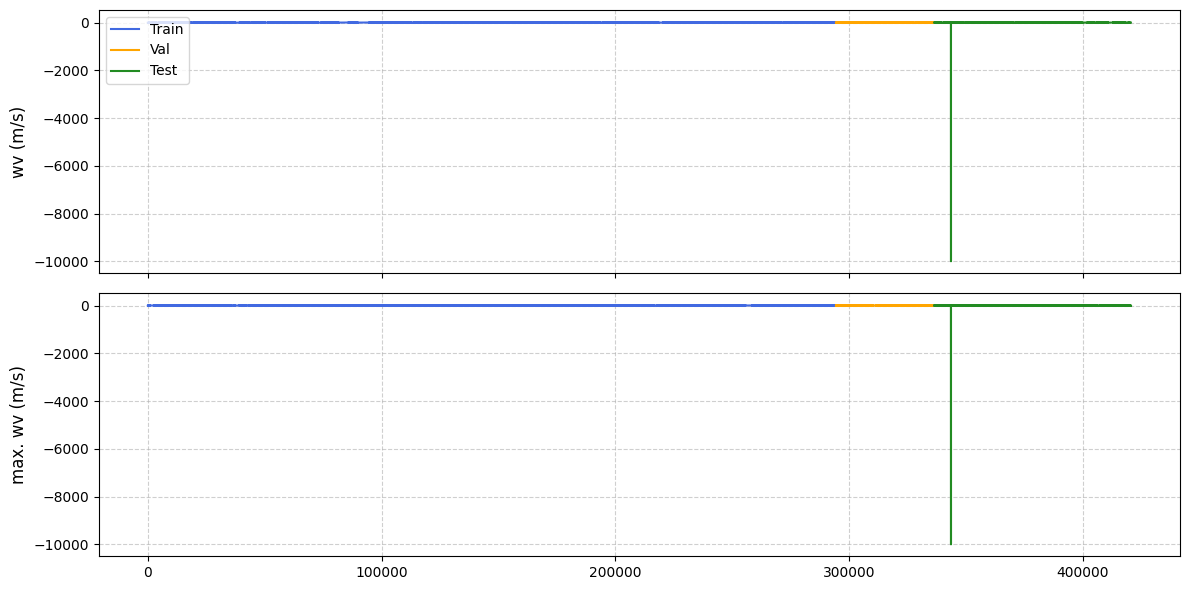

In [56]:
columns_to_plot = df.columns[11:13] 

fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=1, figsize=(12, 3 * len(columns_to_plot)), sharex=True)
if len(columns_to_plot) == 1:
    axes = [axes]
train_end = int(n * 0.7)
val_end = int(n * 0.8)


for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    
    # Train (青), Val (オレンジ), Test (緑)
    ax.plot(df.index[:train_end], df[col].iloc[:train_end], label='Train', color='royalblue')
    ax.plot(df.index[train_end:val_end], df[col].iloc[train_end:val_end], label='Val', color='orange')
    ax.plot(df.index[val_end:], df[col].iloc[val_end:], label='Test', color='forestgreen')
    
    ax.set_ylabel(col, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if i == 0:
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

ということで、全変数の予測値の一部をplotしてみる
全体の形をおえていることはわかる
今回の教訓として、モデル予測の際にはモデルの試作でも、ある程度前処理は大事ってことがわかったのと
このクラスになってくるとモデルの訓練にも１時間程度はかかるので、モデルの改善をしようと思うとかなりの時間がかかることが分かった
結局のところ、いかに初期モデルの性能を高くして、改善が少なく済むようにすべきかっていうのが大事である

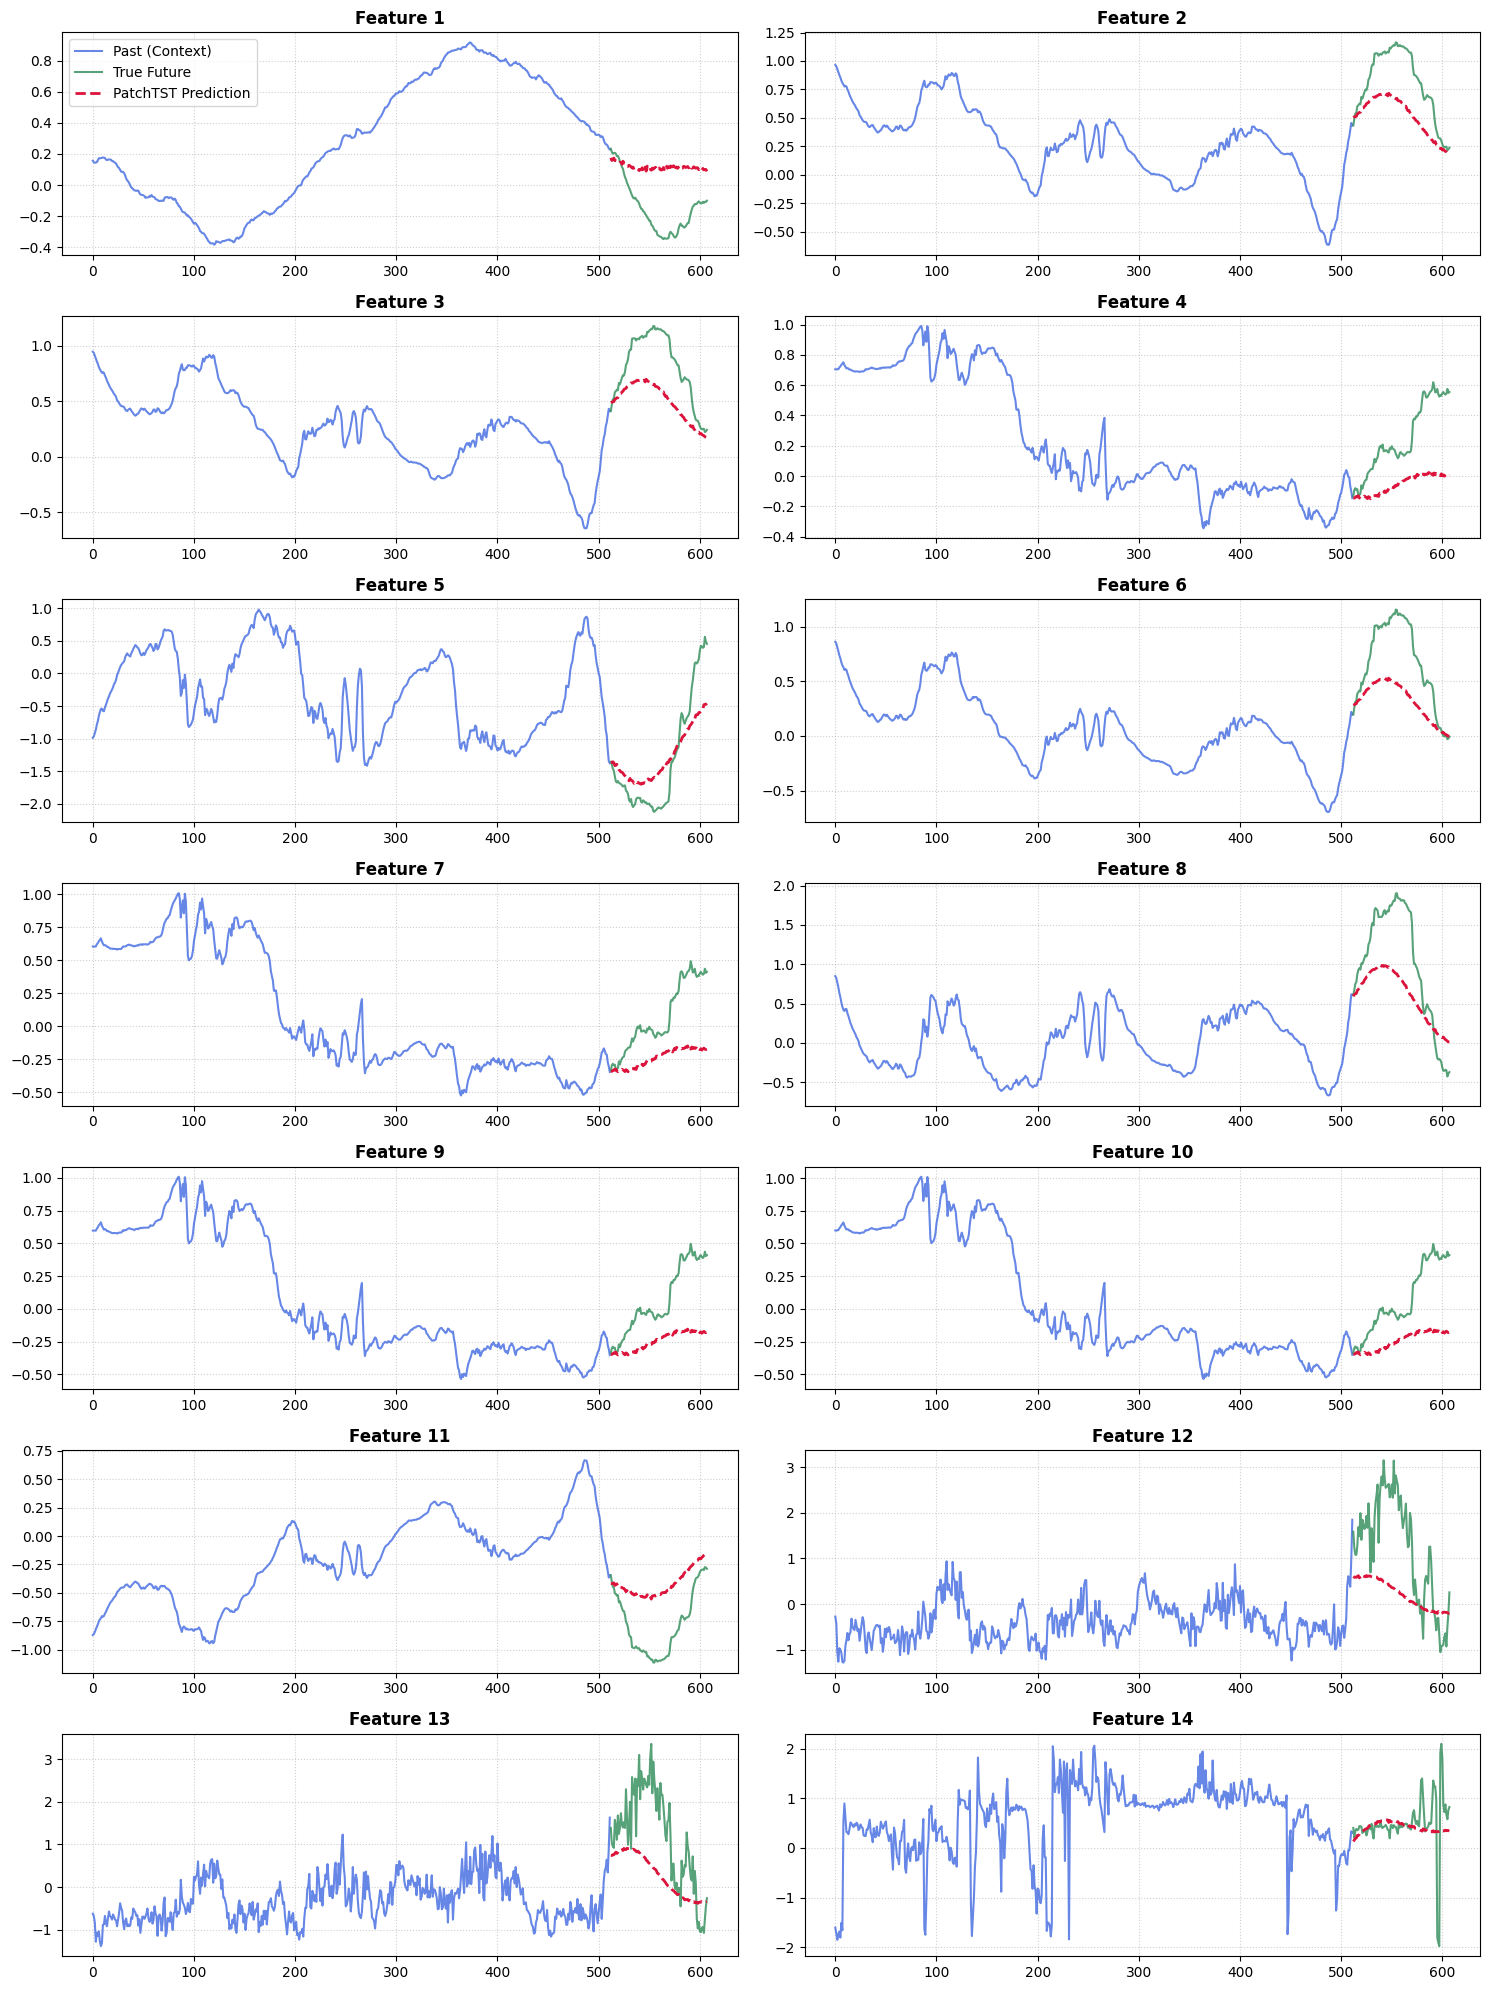

In [ ]:

x_batch, y_batch = next(iter(test_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    outputs = fine_tune_model(past_values=x_batch)
    preds = outputs.prediction_outputs.cpu().numpy() 

x_batch_np = x_batch.cpu().numpy()
y_batch_np = y_batch.numpy()

sample_idx = 0
past_series = x_batch_np[sample_idx]  # 過去データ (512, 14)
true_future = y_batch_np[sample_idx]  # 未来の正解 (96, 14)
pred_future = preds[sample_idx]       # モデルの予測 (96, 14)

fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(15, 20))
axes = axes.flatten()

past_x = np.arange(512)
future_x = np.arange(512, 512 + 96)

channel_names = [f"Feature {i+1}" for i in range(14)]

for i in range(14):
    ax = axes[i]
    ax.plot(past_x, past_series[:, i], label="Past (Context)", color="royalblue", alpha=0.8)
    ax.plot(future_x, true_future[:, i], label="True Future", color="seagreen", alpha=0.8)
    
    ax.plot(future_x, pred_future[:, i], label="PatchTST Prediction", color="crimson", linestyle="--", linewidth=2)
    
    ax.set_title(channel_names[i], fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=":", alpha=0.6)
    if i == 0:
        ax.legend(loc="upper left")

plt.tight_layout()
plt.show()